# TCN Carnatic

For meter tracking in Carnatic music, there have been recent advances in the state of the art using deep learning–based models trained specifically on Carnatic music data. CompIAM provides the TCN-Carnatic beat tracking model as `compiam.rhythm.tcn_carnatic.TCNTracker()`.

This model is based on a Temporal Convolutional Network (TCN) trained on the Carnatic Music Rhythm dataset, followed by Dynamic Bayesian Network (DBN) post-processing. It can predict both beat positions and downbeat positions directly from raw Carnatic music performance audio.

In this documentation, we demonstrate how to use the model and how to visualize the predicted beats and downbeats overlaid on the performance waveform.

We first import the necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import IPython.display as ipd

We load an example audio file from the Saraga Carnatic dataset.

In [2]:
# use an example audio file provided
audio_path = '../data/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Koti Janmani/Koti Janmani.mp3.mp3'

y, sr = librosa.load(audio_path, sr=None)

Here we define a function `plot_and_sonify` that plots and displays the audio, with optional beat and downbeat markers.

The function takes the following parameters:

| Parameter     | Description                                                                 |
|--------------|-----------------------------------------------------------------------------|
| `y`          | Audio signal waveform data.                                                 |
| `sr`         | Sampling rate of the audio signal.                                          |
| `beats`      | Array of beat times (in seconds). If `None`, only the waveform is plotted. |
| `labels`     | Optional array of labels corresponding to beats. Downbeats should be labeled as `1`. |
| `start_time` | Start time in seconds for the plot window (default: `0`).                   |
| `duration`   | Duration in seconds for the plot window. If `None`, the entire signal is plotted. |

In [3]:
def plot_and_sonify(y, sr=22050, beats=None, labels=None, start_time=0, duration=None):
    time = (np.arange(len(y))/sr)

    plt.figure(figsize=(10, 3))

    # Apply time windowing if specified
    plot_y = y
    plot_time = time

    if duration is not None:
        end_time = start_time + duration
        # Find indices for the time window
        start_idx = np.searchsorted(time, start_time)
        end_idx = np.searchsorted(time, end_time)
        plot_time = time[start_idx:end_idx]
        plot_y = y[start_idx:end_idx]

    # Plot waveform
    plt.plot(plot_time, plot_y)
    plt.ylabel('Amplitude')
    plt.xlabel('Time (sec)')
    plt.title("Waveform")

    # Set x-axis limits if duration is specified
    if duration is not None:
        plt.xlim(start_time, start_time + duration)

    # Check if beats are provided
    if beats is not None:
        # Filter beats to the time window if duration is specified
        if duration is not None:
            end_time = start_time + duration
            mask = (beats >= start_time) & (beats <= end_time)
            windowed_beats = beats[mask]
            windowed_labels = labels[mask] if labels is not None else None
        else:
            windowed_beats = beats
            windowed_labels = labels

        # Separate beats into downbeats and other beats
        if windowed_labels is not None:
            windowed_labels = np.array(windowed_labels)  # Ensure labels is a NumPy array
            downbeat_times = windowed_beats[windowed_labels == 1]  # Downbeats (label == 1)
            beat_times = windowed_beats[windowed_labels != 1]      # Other beats (label != 1)
        else:
            downbeat_times = np.array([])  # Empty array for downbeats
            beat_times = windowed_beats    # All beats

        # Plot vertical lines for downbeats and beats
        ylim = np.max(np.abs(plot_y))
        plt.vlines(downbeat_times, ymin=-ylim-0.1, ymax=ylim+0.1, label='DownBeats', color='black', linewidths=1, linestyle='--')
        plt.vlines(beat_times, ymin=-ylim-0.1, ymax=ylim+0.1, label='Beats', color='red', linewidths=1, linestyle=':')

        plt.legend(frameon=True, framealpha=1.0, edgecolor='black', loc='lower left', bbox_to_anchor=(0, 0.05), fontsize='small')

        # Generate click sounds for downbeats and beats
        # Use the windowed audio for click generation
        audio_length = len(plot_y)

        # Adjust beat times relative to the start of the windowed audio
        if duration is not None:
            adjusted_downbeat_times = downbeat_times - start_time
            adjusted_beat_times = beat_times - start_time

            # Filter out negative times and times beyond the audio length
            time_limit = len(plot_y) / sr
            adjusted_downbeat_times = adjusted_downbeat_times[(adjusted_downbeat_times >= 0) & (adjusted_downbeat_times <= time_limit)]
            adjusted_beat_times = adjusted_beat_times[(adjusted_beat_times >= 0) & (adjusted_beat_times <= time_limit)]
        else:
            adjusted_downbeat_times = downbeat_times
            adjusted_beat_times = beat_times

        downbeat_click = librosa.clicks(times=adjusted_downbeat_times, sr=sr, click_freq=1000, length=audio_length, click_duration=0.1)
        beat_click = librosa.clicks(times=adjusted_beat_times, sr=sr, click_freq=500, length=audio_length, click_duration=0.1)

        # Combine original audio with clicks
        combined_audio = plot_y + beat_click + downbeat_click

        # Normalize combined audio to prevent clipping
        combined_audio = combined_audio / np.max(np.abs(combined_audio))

    else:
        combined_audio = plot_y

    # Play the audio with clicks
    audio_widget = ipd.Audio(combined_audio, rate=sr)
    
    return audio_widget

Now we plot and display the loaded audio waveform.  
We define `start_time` and `duration` to specify the segment of the audio to be visualized.

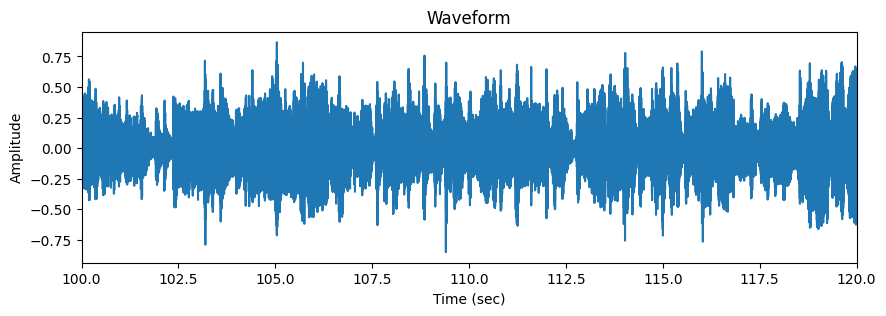

In [4]:
start_time = 100.0  # in seconds
duration = 20.0

plot_and_sonify(y=y, sr=sr, start_time=start_time, duration=duration)

Now we import `compiam` to use the model.

> **Note:** In order to use `compiam.rhythm.tcn_carnatic.TCNTracker()`, you need to install `torch` and `madmom`.  
> `madmom` is used for post-processing the TCN output.

Run the following command to install the necessary dependencies to use TCN-Carnatic.

In [9]:
%%capture
!pip install torch
!pip install "madmom @ git+https://github.com/vivekvjyn/madmom.git"

In [10]:
import compiam

Now load the model by calling `compiam.load_model('rhythm:tcn-carnatic')`, which will automatically download and load the model.

In [11]:
tracker = compiam.load_model('rhythm:tcn-carnatic')

AttributeError: module 'compiam' has no attribute 'load_model'

Now pass the `audio_path` to the `predict` method.  
Alternatively, you can pass the audio signal (`y`) and sampling rate (`sr`) directly.

In [17]:
prediction = tracker.predict(audio_path)

/home/vivek/miniconda3/envs/madmom/lib/python3.9/site-packages/madmom/features/downbeats.py:287: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  best = np.argmax(np.asarray(results)[:, 1])


The output is a `numpy.ndarray` of shape `(n, 2)`, where `n` is the number of predicted beats.  

It contains:
- Predicted beat times in seconds.
- Beat labels, indicating the position of the beat relative to the downbeat. Downbeats are labeled as `1`.

Here, we extract the `beats` and `labels` from the `prediction`.

In [18]:
beats = prediction[:, 0]
labels = prediction[:, 1]

Now we can plot and listen to the predicted beats by calling the `plot_and_sonify` function.  

This time, we pass in the `beats` and `labels` as well, so that:
- Beats and downbeats are marked on the plot with red and black dotted lines, respectively.
- The output audio includes clicks on the beats, with slightly higher-pitched clicks for the downbeats.

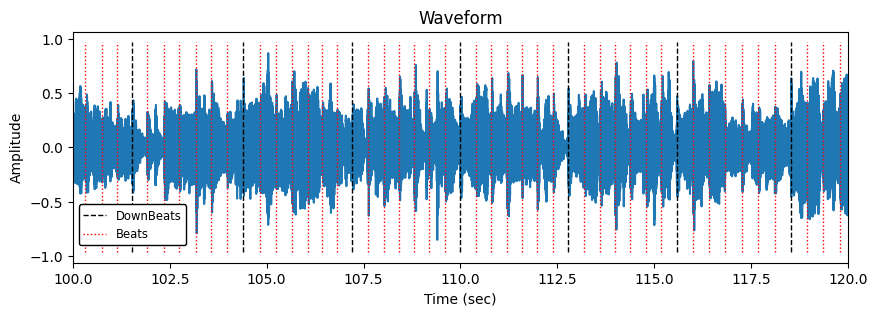

In [24]:
plot_and_sonify(y, sr=sr, beats=beats, labels=labels, start_time=start_time, duration=duration)